
Analyzing age:
Variable Type: continuous

Statistics:
mean_good: 40.268
mean_bad: 40.016
std_good: 9.887
std_bad: 9.578
t_statistic: 0.372
p_value: 0.710
ks_statistic: 0.046
information_value: 0.016

Interpretation:
- No statistically significant difference between populations
- Predictive power: Very weak (IV = 0.016)


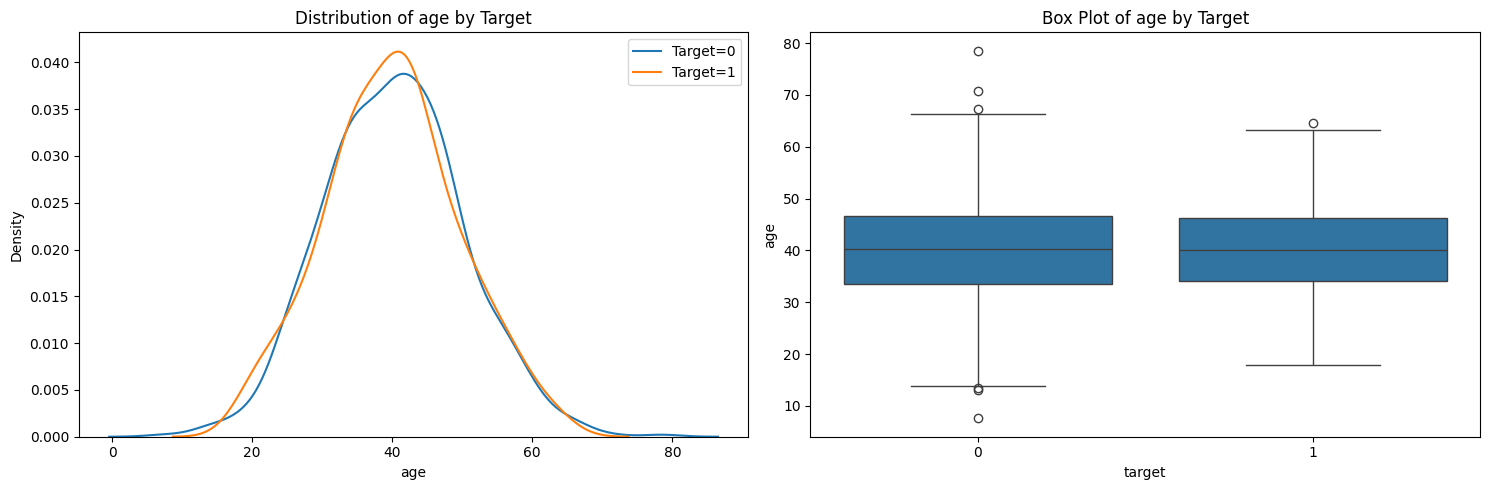


Analyzing income:
Variable Type: continuous

Statistics:
mean_good: 38675.405
mean_bad: 38305.456
std_good: 47363.167
std_bad: 47736.318
t_statistic: 0.112
p_value: 0.910
ks_statistic: 0.041
information_value: 0.035

Interpretation:
- No statistically significant difference between populations
- Predictive power: Weak (IV = 0.035)


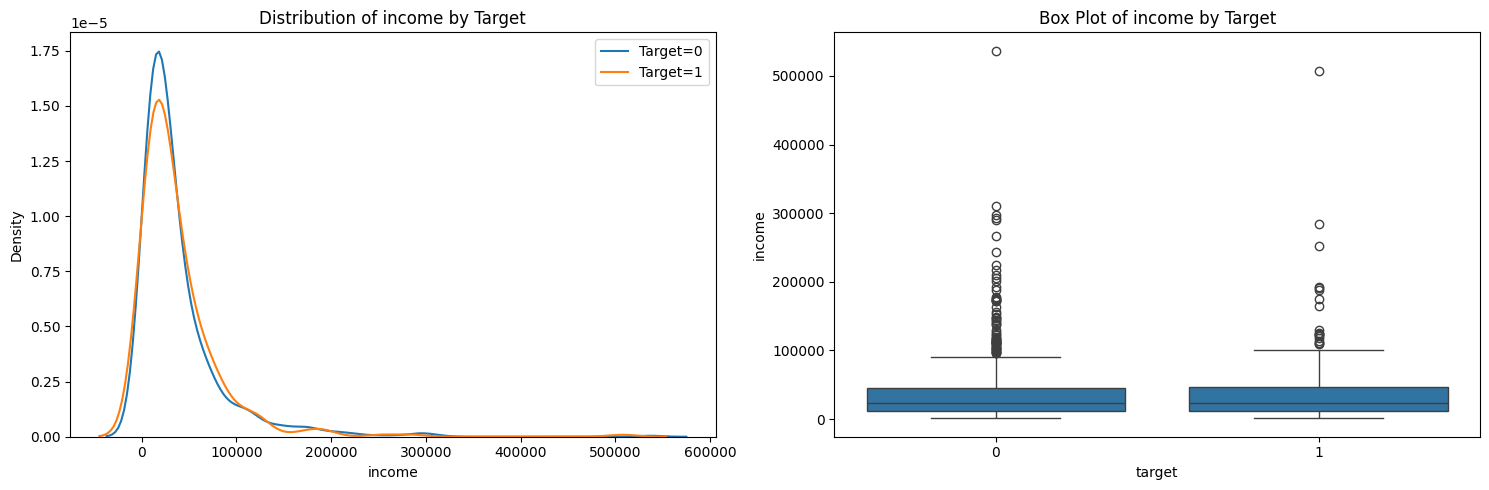


Analyzing education:
Variable Type: categorical

Statistics:
chi2_statistic: 1.094
p_value: 0.778
information_value: 0.005

woe_by_category:
  Bachelor: -0.071
  Master: 0.124
  PhD: -0.045
  HS: -0.001

Interpretation:
- No significant relationship with target variable
- Predictive power: Very weak (IV = 0.005)


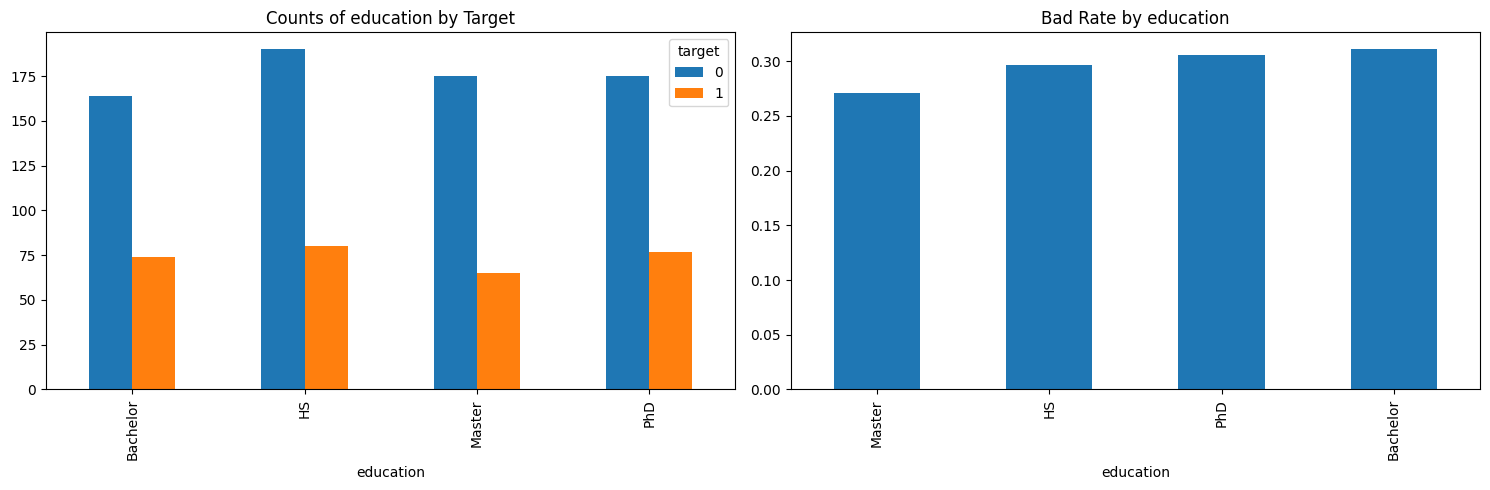


Analyzing credit_score:
Variable Type: continuous

Statistics:
mean_good: 575.756
mean_bad: 576.284
std_good: 158.252
std_bad: 152.956
t_statistic: -0.049
p_value: 0.961
ks_statistic: 0.045
information_value: 0.027

Interpretation:
- No statistically significant difference between populations
- Predictive power: Weak (IV = 0.027)


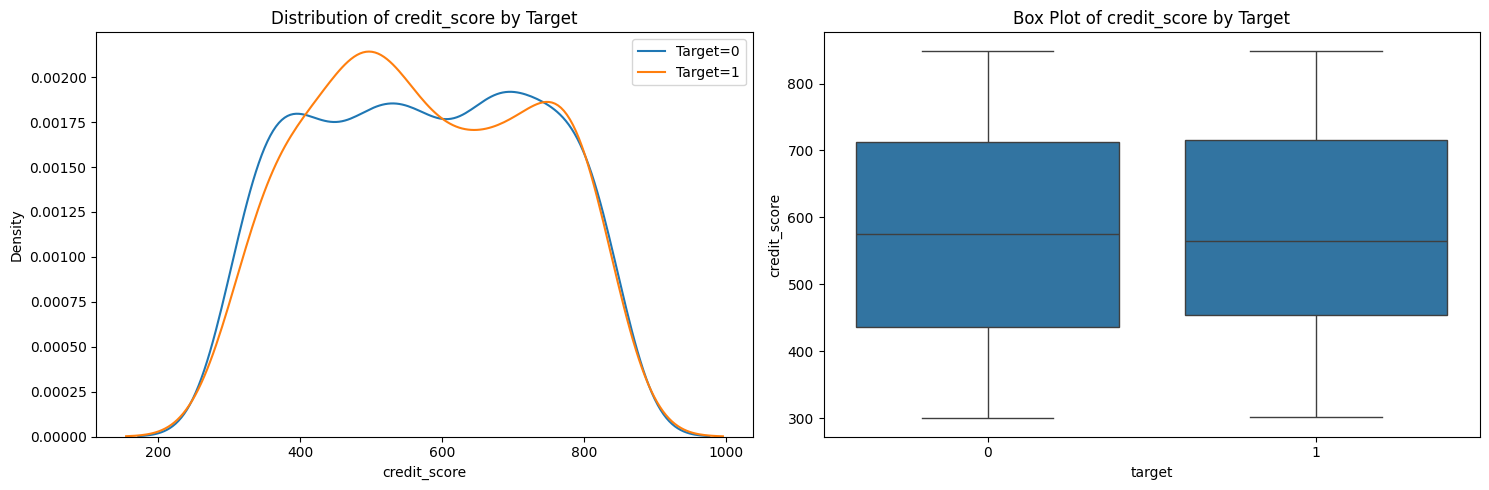


Analyzing num_accounts:
Variable Type: categorical

Statistics:
chi2_statistic: 12.708
p_value: 0.013
information_value: 0.061

woe_by_category:
  5: -0.017
  3: 0.213
  4: -0.340
  2: 0.348
  1: -0.158

Interpretation:
- Significant relationship with target variable
- Predictive power: Weak (IV = 0.061)


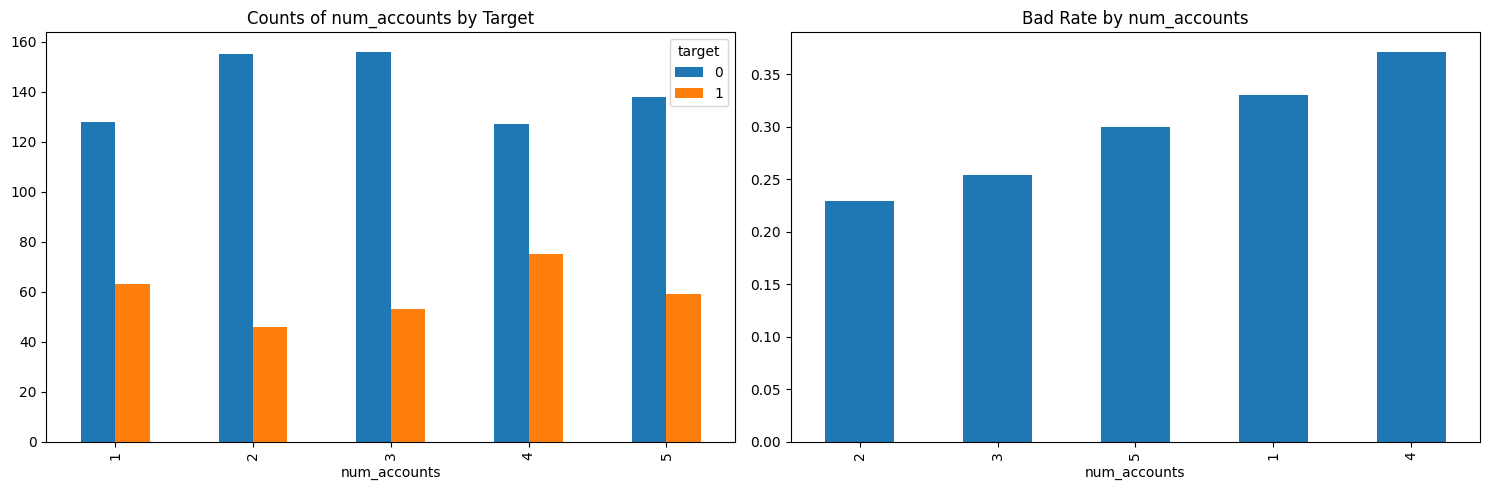

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

class FeatureAnalysis:
    def __init__(self, data, target_col='target'):
        self.data = data
        self.target_col = target_col
        self.analysis_results = {}
        
    def analyze_continuous_variable(self, column):
        """Analyze continuous variable relationship with target"""
        # Statistical tests
        good = self.data[self.data[self.target_col] == 0][column]
        bad = self.data[self.data[self.target_col] == 1][column]
        
        t_stat, p_value = stats.ttest_ind(good, bad)
        ks_stat, ks_p = stats.ks_2samp(good, bad)
        
        # Calculate IV (Information Value)
        bins = pd.qcut(self.data[column], q=10, duplicates='drop')
        iv_table = pd.crosstab(bins, self.data[self.target_col])
        good_dist = iv_table[0] / iv_table[0].sum()
        bad_dist = iv_table[1] / iv_table[1].sum()
        iv = np.sum((good_dist - bad_dist) * np.log(good_dist / bad_dist))
        
        analysis = {
            'variable_type': 'continuous',
            'statistics': {
                'mean_good': good.mean(),
                'mean_bad': bad.mean(),
                'std_good': good.std(),
                'std_bad': bad.std(),
                't_statistic': t_stat,
                'p_value': p_value,
                'ks_statistic': ks_stat,
                'information_value': iv
            },
            'interpretation': self._interpret_continuous_analysis(
                t_stat, p_value, ks_stat, iv)
        }
        
        return analysis
    
    def analyze_categorical_variable(self, column):
        """Analyze categorical variable relationship with target"""
        # Chi-square test
        contingency = pd.crosstab(self.data[column], self.data[self.target_col])
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
        
        # Calculate IV
        total_good = contingency[0].sum()
        total_bad = contingency[1].sum()
        good_dist = contingency[0] / total_good
        bad_dist = contingency[1] / total_bad
        iv = np.sum((good_dist - bad_dist) * np.log(good_dist / bad_dist))
        
        # Calculate WOE for each category
        woe_dict = {}
        for category in self.data[column].unique():
            good_rate = good_dist[category]
            bad_rate = bad_dist[category]
            woe = np.log(good_rate / bad_rate)
            woe_dict[category] = woe
        
        analysis = {
            'variable_type': 'categorical',
            'statistics': {
                'chi2_statistic': chi2,
                'p_value': p_value,
                'information_value': iv,
                'woe_by_category': woe_dict
            },
            'interpretation': self._interpret_categorical_analysis(
                chi2, p_value, iv, woe_dict)
        }
        
        return analysis
    
    def _interpret_continuous_analysis(self, t_stat, p_value, ks_stat, iv):
        """Interpret continuous variable analysis results"""
        interpretations = []
        
        # Statistical significance
        if p_value < 0.05:
            interpretations.append("Statistically significant difference between good and bad populations")
        else:
            interpretations.append("No statistically significant difference between populations")
        
        # Effect size (IV interpretation)
        if iv < 0.02:
            predictive_power = "Very weak"
        elif iv < 0.1:
            predictive_power = "Weak"
        elif iv < 0.3:
            predictive_power = "Medium"
        else:
            predictive_power = "Strong"
        
        interpretations.append(f"Predictive power: {predictive_power} (IV = {iv:.3f})")
        
        # Distribution difference
        if ks_stat > 0.1:
            interpretations.append("Substantial difference in distributions between good and bad")
        
        return interpretations
    
    def _interpret_categorical_analysis(self, chi2, p_value, iv, woe_dict):
        """Interpret categorical variable analysis results"""
        interpretations = []
        
        # Statistical significance
        if p_value < 0.05:
            interpretations.append("Significant relationship with target variable")
        else:
            interpretations.append("No significant relationship with target variable")
        
        # Effect size (IV interpretation)
        if iv < 0.02:
            predictive_power = "Very weak"
        elif iv < 0.1:
            predictive_power = "Weak"
        elif iv < 0.3:
            predictive_power = "Medium"
        else:
            predictive_power = "Strong"
        
        interpretations.append(f"Predictive power: {predictive_power} (IV = {iv:.3f})")
        
        # WOE patterns
        woe_range = max(woe_dict.values()) - min(woe_dict.values())
        if woe_range > 1:
            interpretations.append("Strong differentiation between categories")
        
        return interpretations
    
    def analyze_all_features(self):
        """Analyze all features and their relationships with target"""
        for column in self.data.columns:
            if column == self.target_col:
                continue
            
            print(f"\nAnalyzing {column}:")
            print("=" * 50)
            
            if self.data[column].dtype in ['int64', 'float64']:
                if len(self.data[column].unique()) > 10:
                    analysis = self.analyze_continuous_variable(column)
                else:
                    analysis = self.analyze_categorical_variable(column)
            else:
                analysis = self.analyze_categorical_variable(column)
            
            self.analysis_results[column] = analysis
            
            print(f"Variable Type: {analysis['variable_type']}")
            print("\nStatistics:")
            for stat, value in analysis['statistics'].items():
                if isinstance(value, dict):
                    print(f"\n{stat}:")
                    for k, v in value.items():
                        print(f"  {k}: {v:.3f}")
                else:
                    print(f"{stat}: {value:.3f}")
            
            print("\nInterpretation:")
            for interp in analysis['interpretation']:
                print(f"- {interp}")
            
            # Plot the variable
            self.plot_variable(column)
            plt.show()
    
    def plot_variable(self, column):
        """Plot variable with appropriate visualization"""
        if self.data[column].dtype in ['int64', 'float64']:
            if len(self.data[column].unique()) > 10:
                self.plot_continuous_variable(column)
            else:
                self.plot_categorical_variable(column)
        else:
            self.plot_categorical_variable(column)
    
    def plot_continuous_variable(self, column):
        """Plot continuous variable"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Distribution plot
        for target in [0, 1]:
            sns.kdeplot(
                data=self.data[self.data[self.target_col] == target][column],
                label=f'Target={target}',
                ax=ax1
            )
        ax1.set_title(f'Distribution of {column} by Target')
        ax1.legend()
        
        # Box plot
        sns.boxplot(x=self.target_col, y=column, data=self.data, ax=ax2)
        ax2.set_title(f'Box Plot of {column} by Target')
        
        plt.tight_layout()
    
    def plot_categorical_variable(self, column):
        """Plot categorical variable"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Count plot
        pd.crosstab(self.data[column], 
                   self.data[self.target_col]).plot(kind='bar', ax=ax1)
        ax1.set_title(f'Counts of {column} by Target')
        
        # Bad rate plot
        bad_rate = (pd.crosstab(self.data[column], 
                               self.data[self.target_col], 
                               normalize='index')[1]
                   .sort_values())
        bad_rate.plot(kind='bar', ax=ax2)
        ax2.set_title(f'Bad Rate by {column}')
        
        plt.tight_layout()

# Example usage
def demonstrate_analysis():
    # Create example data
    np.random.seed(42)
    n_samples = 1000
    
    data = pd.DataFrame({
        'age': np.random.normal(40, 10, n_samples),
        'income': np.random.lognormal(10, 1, n_samples),
        'education': np.random.choice(['HS', 'Bachelor', 'Master', 'PhD'], n_samples),
        'credit_score': np.random.randint(300, 850, n_samples),
        'num_accounts': np.random.randint(1, 6, n_samples),
        'target': np.random.binomial(1, 0.3, n_samples)
    })
    
    analyzer = FeatureAnalysis(data)
    analyzer.analyze_all_features()
    
    return analyzer

# Run analysis
analyzer = demonstrate_analysis()